<div style="box-sizing:border-box;max-width:100%;margin:0 0 8px;padding:4px 0;color:inherit;line-height:1.35;"><img src="https://thetahat.ru/images/logo_thetahat.png" alt="ThetaHat" style="display:block!important;width:52px!important;max-width:52px!important;height:auto!important;margin:0 0 9px 0!important;padding:0!important;"><div style="display:flex;align-items:center;justify-content:space-between;flex-wrap:wrap;gap:8px 12px;"><span style="min-width:0;color:inherit;font-size:12px;font-weight:700;letter-spacing:0.055em;text-transform:uppercase;"><a href="https://thetahat.ru/courses/ysda-group" style="color:inherit;text-decoration:none;">Школа анализа данных</a>&nbsp;·&nbsp;Машинное обучение</span></div></div>

<h2><span style="display:block;box-sizing:border-box;max-width:100%;padding:16px 22px 17px;border-radius:14px;background:linear-gradient(135deg,#D4470E 0%,#C7324E 50%,#B316B8 100%);color:#FFFFFF;line-height:1.15;font-weight:500;">Лекция.  Калибровки предсказаний вероятности</span></h2>

В этом ноутбуке рассмотрен подход к проверке качества предсказания вероятностей классов моделями в случае бинарной классификации, а также методы калибровки этих вероятностей.

In [81]:
import numpy as np
import pandas as pd
import scipy.stats as sps
import warnings

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import brier_score_loss, log_loss

import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sns.set(style="darkgrid", font_scale=1.2, palette="Set2")

### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">1</span> <span style="color:inherit;">Анализ предсказаний вероятностей</span>

#### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">1.1</span> <span style="color:inherit;">Мотивация</span>

При решении задачи классификаци нам часто требуется помимо метки класса предсказать еще и вероятность принадлежности соответствующему классу. Использование оценок вероятностей позволяет дать более полный ответ и оставляет некоторую гибкость при решении задачи.
* Например, для оценки бизнес-рисков требуется несмещенно оценить вероятности.
* Или же для оценки риска осложнений после планируемой медицинской операции.
* Кроме того, даже если нам не нужны сами вероятности, мы можем легко поменять порог для бинарной классификации и получить некоторый прирост по целевым метриками.

При использовании моделей, которые предсказывают вероятности, хотелось бы, чтобы оценки вероятностей хорошо оценивали сами вероятности. Другими словами, если мы рассмотрим множество объектов, для которых $\widehat{p} \approx 0.8$, то разумно ожидать, что около $80\%$ из этих рассмотренных объектов действительно имеют положительную метку. Отклонение может оказаться критичным, например, в задаче кредитного скоринга, где недооценка рисков может привести к потере средств.

---

Рассмотрим задачу кредитного скоринга.

Банк хочет автоматизировать процесс одобрения кредитов. Модель машинного обучения должна предсказать вероятность дефолта ($PD — \text{Probability of Default}$) для каждого потенциального заемщика на основе его данных (доход, кредитная история, возраст и т.д.).


Правила принятия решений:
- $\text{PD} \lt 2\%$ – кредит одобряется по стандартной ставке.  
- $2\% \le \text{PD} \lt 5\%$ – кредит одобряется, но по повышенной ставке.  
- $5\% \le \text{PD} \lt 10\%$ – требуется дополнительная проверка.  
- $\text{PD} \ge 10\%$ – кредит отклоняется.  


Возьмем датасет [Give Me Some Credit](https://www.kaggle.com/c/GiveMeSomeCredit/data) — один из классических датасетов для задач кредитного скоринга.

**Таргет** `SeriousDlqin2yrs`:  
  - `1` — клиент не смог погасить кредит (дефолт в течение ближайших 2 лет)  
  - `0` — клиент исправно выплачивал кредит  

**Признаки:**
- `RevolvingUtilizationOfUnsecuredLines` — коэффициент использования кредитных карт и других незакреплённых кредитных линий (отношение задолженности к лимиту)  

- `age` — возраст клиента (в годах)  
- `NumberOfTime30-59DaysPastDueNotWorse` — сколько раз клиент задерживал платежи на 30–59 дней за последние 2 года  
- `DebtRatio` — соотношение ежемесячных расходов на долги к ежемесячному доходу  
- `MonthlyIncome` — ежемесячный доход клиента  
- `NumberOfOpenCreditLinesAndLoans` — количество открытых кредитных линий и кредитов  
- `NumberOfTimes90DaysLate` — сколько раз клиент задерживал платежи более чем на 90 дней  
- `NumberRealEstateLoansOrLines` — количество ипотек и других кредитов под залог недвижимости  
- `NumberOfTime60-89DaysPastDueNotWorse` — сколько раз клиент задерживал платежи на 60–89 дней за последние 2 года  
- `NumberOfDependents` — количество иждивенцев  


In [82]:
df = pd.read_csv("cs-training.csv", index_col=0)
df.rename(columns={"SeriousDlqin2yrs": "default"}, inplace=True)

y = df["default"]
X = df.drop("default", axis=1)

imputer = SimpleImputer(strategy="median")
X[X.columns] = imputer.fit_transform(X[X.columns])

df.head()

,default,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


Разделелим данные на обучающую, калибровочную и тестовую выборки.

In [83]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_calib, y_train, y_calib = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

Обучим kNN предсказывать одобрение кредита.

In [84]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)

y_pred_proba_uncalibrated = knn.predict_proba(X_test)[:, 1]
y_pred = knn.predict(X_test)

Теперь применим обученную модель к тестовой выборке. Посмотрим на клиентов, которых модель отнесла к категории низкого риска и рекомендовала бы одобрить кредит без дополнительных проверок.

In [85]:
def get_credit_risk_decisions(true_labels, predicted_probabilities):
    """
    Создает сводную таблицу с анализом качества модели по категориям риска.

    true_labels -- истинные метки (1 - дефолт, 0 - исправный заемщик)
    predicted_probabilities -- предсказанные вероятности дефолта
    """

    conditions = [
        (predicted_probabilities < 0.02),
        (predicted_probabilities < 0.05),
        (predicted_probabilities < 0.10),
        (predicted_probabilities >= 0.10),
    ]

    choices = [
        "Одобрить (стандартная ставка)",
        "Одобрить (повышенная ставка)",
        "Дополнительная проверка",
        "Отклонить",
    ]

    # Исправление: явно указываем dtype=object
    decisions = np.select(conditions, choices, default="Отклонить")

    detailed_results = pd.DataFrame(
        {
            "actual_default_flag": np.array(true_labels).astype(int),
            "predicted_default_probability": predicted_probabilities,
            "risk_category": decisions,
        }
    )

    risk_analysis = (
        detailed_results.groupby("risk_category")
        .agg(
            {
                "predicted_default_probability": "mean",
                "actual_default_flag": ["mean", "count", "sum"],
            }
        )
        .round(4)
    )

    risk_analysis.columns = [
        "Предсказанная вероятность дефолта",
        "Фактическая вероятность дефолта",
        "Количество заемщиков",
        "Количество дефолтов",
    ]

    risk_analysis = risk_analysis.reset_index()

    category_order = [
        "Одобрить (стандартная ставка)",
        "Одобрить (повышенная ставка)",
        "Дополнительная проверка",
        "Отклонить",
    ]

    risk_analysis["risk_category"] = pd.Categorical(
        risk_analysis["risk_category"], categories=category_order, ordered=True
    )

    risk_analysis = risk_analysis.sort_values("risk_category").reset_index(drop=True)

    return risk_analysis

In [86]:
risk_table = get_credit_risk_decisions(y_test.values, y_pred_proba_uncalibrated)

print(
    f"Стандартная ставка: предполагается {int(risk_table['Количество заемщиков'][0] * risk_table['Предсказанная вероятность дефолта'][0])} дефолтов"
)
risk_table

Стандартная ставка: предполагается 0 дефолтов


,risk_category,Предсказанная вероятность дефолта,Фактическая вероятность дефолта,Количество заемщиков,Количество дефолтов
0,Одобрить (стандартная ставка),0.0000,0.0518,18110,939
1,Отклонить,0.1374,0.0897,11890,1066


Видим, что по модель недооценивает риски:
- В группе со *страндартной ставкой* предсказано 0% дефолтов, но фактически 5.18% (939 дефолтов)
- В группу с *повышенной ставкой* и *дополнительной проверкой* модель не определила никого


**Вывод:** Модель демонстрирует плохую калибровку вероятностей. Она непригодна для практического применения в кредитном скоринге, так как систематически занижает риски, что может привести к существенным финансовым потерям.

---

Решение – откалибровать модель. Калибровка помогает привести предсказанные вероятности к реальным частотам.


#### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">1.2</span> <span style="color:inherit;">Калибровочная кривая</span>

Построить калибровочную кривую можно одним их следующих вариантов

1. `sklearn.calibration.CalibrationDisplay(prob_true, prob_pred, y_prob, *, estimator_name=None, pos_label=None)`

  * `prob_true`, размер `(n_bins,)` &mdash; доля объектов класса 1 в бине;
  * `prob_pred`, размер `(n_bins,)` &mdash; среднее предсказание в бине;
  * `y_prob`, размер `(n_samples,)` &mdash; оценки вероятностей класса 1 для элементов выборки.


2. `sklearn.calibration.CalibrationDisplay.from_estimator(estimator, X, y, *[, n_bins, ...])`

  * `estimator` &mdash; обученный классификатор;
  * `X`, `y` &mdash; тестовая выборка.
  

3. `sklearn.calibration.CalibrationDisplay.from_predictions(y_true, y_prob, *[, ...])`

  * `y_true`, размер `(n_samples,)` &mdash; метки класса;
  * `y_prob`, размер `(n_samples,)` &mdash; оценки вероятностей класса 1 для элементов выборки;



In [87]:
def calibration_curves(clf_list, figsize=(12, 7)):
    """
    Отрисовка калибровочной кривой.

    clf_list -- список кортежей (обученный классификатор, его название)
    figsize -- размер фигуры
    """

    f, ax = plt.subplots(figsize=figsize)

    for i, (clf, name) in enumerate(clf_list):
        probs = clf.predict_proba(X_test)[:, 1]
        CalibrationDisplay.from_predictions(
            y_test, probs, n_bins=20, lw=3, name=name, ax=ax, strategy="quantile"
        )
    ax.set_xlabel("Предсказанная вероятность (среднее внутри бина)")
    ax.set_ylabel("Доля класса 1 в бине")
    ax.set_title("Сравнение калибровочных кривых")
    plt.legend(fontsize=15)
    plt.tight_layout()
    plt.show()

Посмотрим, как откалиброван обученный Random Forest.

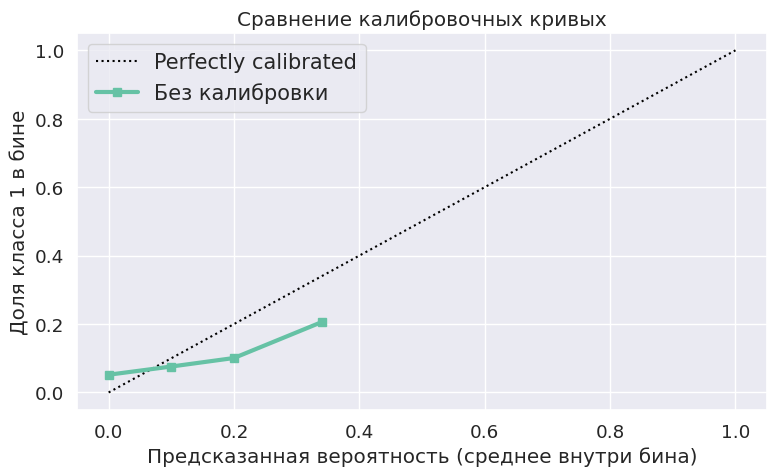

In [88]:
clf_list = [
    (knn, "Без калибровки"),
]

calibration_curves(clf_list, figsize=(8, 5))

Классификатор получился плохо откалиброванным:

- В области, где кривая лежит выше диагонали (там, где кредит одобряется автоматически), модель слишком уверена в отсутствии дефолта. Это означает, что банк будет недооценивать риск и одобрять слишком много заявок от потенциально рискованных клиентов.

- В области отклонённых кредитов модель, наоборот, недооценивает вероятность дефолта. Это приводит к тому, что часть клиентов считаются более надёжными, чем есть на самом деле

#### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">1.3</span> <span style="color:inherit;">Методы калибровки</span>

Калибровку вероятностей методами изотонической регрессии и Платта можно выполнить с помощью класса

`sklearn.calibration.CalibratedClassifierCV(base_estimator=None, *, method='sigmoid', cv=None, n_jobs=None, ensemble=True)`

*Основные аргументы:*
* `base_estimator` &mdash; классификатор, предсказания которого следует откалибровать;
* `method` &mdash; методы калибровки
  * `‘sigmoid’` &mdash; метод Платта,
  * `‘isotonic’` &mdash; изотоническая регрессия;
* `cv` &mdash; стратегия кросс-валидации для обучения и калибровки; если равно `“prefit”`, то считается, что модель уже обучена, и вся новая выборка идет на калибровку.

*Методы:*
* `fit(X, y[, sample_weight])` &mdash; обучение модели;
* `predict(X)` &mdash; предсказания;
* `predict_proba(X)` &mdash; откалиброванные предсказания вероятностей.

Разберемся, как эти методы изменяют исходные предсказания.

**Метод Платта.** Преобразуем исходный скор $s$ с помощью сигмоиды:

$$
\widehat{p}_{\mathrm{cal}} = \sigma(as+b), \qquad
\sigma(z) = \frac{1}{1+e^{-z}}.
$$

Параметры $a$ и $b$ подбираются по калибровочной выборке. Для kNN исходным скором служит предсказанная вероятность класса 1, а для логистической регрессии — значение логита. Метод позволяет изменить масштаб и смещение исходного скора.

**Изотоническая регрессия.** Обучаем более гибкое преобразование $\widehat{p}_{\mathrm{cal}}=g(s)$. Форма функции заранее не задается, но она должна быть неубывающей: большему скору соответствует не меньшая вероятность. Такой метод может исправить более сложные искажения, но для его обучения требуется достаточно данных.

Оба метода обучаем на отдельной калибровочной выборке. На обучающей выборке модель обычно предсказывает лучше, чем на новых объектах; калибровка по этим предсказаниям может сделать вероятности слишком уверенными. Тестовую выборку оставляем для оценки результата.

Применим калибровку методом Платта и изотонической регрессии.

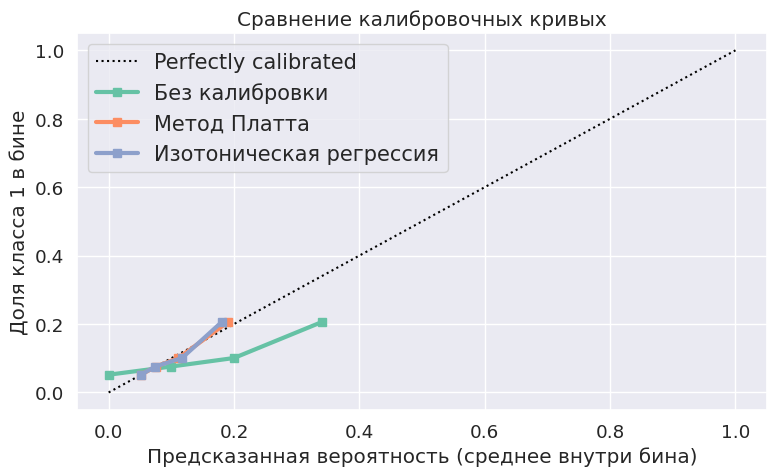

In [89]:
knn_platt = CalibratedClassifierCV(knn, method="sigmoid", cv="prefit")
knn_platt.fit(X_calib, y_calib)
y_pred_proba_platt = knn_platt.predict_proba(X_test)[:, 1]

knn_isotonic = CalibratedClassifierCV(knn, method="isotonic", cv="prefit")
knn_isotonic.fit(X_calib, y_calib)
y_pred_proba_isotonic = knn_isotonic.predict_proba(X_test)[:, 1]

clf_list = [
    (knn, "Без калибровки"),
    (knn_platt, "Метод Платта"),
    (knn_isotonic, "Изотоническая регрессия"),
]

calibration_curves(clf_list, figsize=(8, 5))

После обоих методов калибровки кривая прибоизилась к идеальной – предсказанные вероятности стали соответствовать реальным частотам дефолта.


In [90]:
risk_table_platt = get_credit_risk_decisions(y_test.values, y_pred_proba_platt)
risk_table_platt

,risk_category,Предсказанная вероятность дефолта,Фактическая вероятность дефолта,Количество заемщиков,Количество дефолтов
0,Дополнительная проверка,0.059,0.0595,26616,1584
1,Отклонить,0.129,0.1244,3384,421


In [91]:
risk_table_isotonic = get_credit_risk_decisions(y_test.values, y_pred_proba_isotonic)
risk_table_isotonic

,risk_category,Предсказанная вероятность дефолта,Фактическая вероятность дефолта,Количество заемщиков,Количество дефолтов
0,Дополнительная проверка,0.0589,0.0595,26616,1584
1,Отклонить,0.1313,0.1244,3384,421


Оба метода калибровки демонстрируют высокую эффективность.

**Вывод:**
Калибровка устранила основную проблему модели: предсказанные вероятности стали соответствовать реальным частотам дефолтов.

Для кредитного скоринга это принципиально важно: теперь вероятность, выдаваемая моделью, можно напрямую интерпретировать как риск невозврата.

Таким образом, модель можно использовать для более обоснованных решений об одобрении или отклонении заявок, опираясь на заранее заданные пороговые значения риска.



### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">2</span> <span style="color:inherit;">Калибровка логистической регрессии</span>

Рассмотрим два простых примера, а затем вернемся к задаче кредитного скоринга и сравним логистическую регрессию с kNN.

In [92]:
# Сохраним исходное разбиение кредитного датасета
X_train_credit, X_calib_credit, X_test_credit = X_train, X_calib, X_test
y_train_credit, y_calib_credit, y_test_credit = y_train, y_calib, y_test

In [93]:
def calibrated_classifier(clf, X_calib, y_calib, method):
    """
    Калибровка уже обученного классификатора на отдельной выборке.

    clf -- обученный классификатор
    X_calib, y_calib -- калибровочная выборка
    method -- 'sigmoid' или 'isotonic'
    """

    # FrozenEstimator сохраняет обученную модель без повторного обучения
    try:
        from sklearn.frozen import FrozenEstimator
    except ImportError:
        calibrated = CalibratedClassifierCV(clf, method=method, cv="prefit")
    else:
        calibrated = CalibratedClassifierCV(FrozenEstimator(clf), method=method)

    return calibrated.fit(X_calib, y_calib)


def calibration_curves_lr(
    clf_list, X_eval, y_eval, figsize=(8, 5), ax=None, title="Сравнение калибровочных кривых"
):
    """
    Отрисовка калибровочных кривых на заданной выборке.

    clf_list -- список кортежей (обученный классификатор, его название)
    X_eval, y_eval -- выборка для оценки
    figsize -- размер фигуры
    ax -- оси для отрисовки, если фигура уже создана
    title -- заголовок графика
    """

    own_figure = ax is None
    if own_figure:
        _, ax = plt.subplots(figsize=figsize)

    for clf, name in clf_list:
        probs = clf.predict_proba(X_eval)[:, 1]
        CalibrationDisplay.from_predictions(
            y_eval, probs, n_bins=20, lw=3, name=name, ax=ax, strategy="quantile"
        )

    ax.set_xlabel("Предсказанная вероятность\n(среднее внутри бина)")
    ax.set_ylabel("Доля класса 1 в бине")
    ax.set_title(title)
    ax.legend(fontsize=13)

    if own_figure:
        plt.tight_layout()
        plt.show()

In [94]:
def draw_prob_predictions_lr(clf, X_eval, y_eval, name, step=0.1, ax=None):
    """
    Отрисовка предсказаний вероятности класса 1 для двух признаков.

    clf -- обученный классификатор
    X_eval, y_eval -- выборка и ее истинные метки
    name -- имя классификатора
    step -- шаг сетки
    ax -- оси для отрисовки, если фигура уже создана
    """

    x_min, x_max = X_eval[:, 0].min(), X_eval[:, 0].max()
    y_min, y_max = X_eval[:, 1].min(), X_eval[:, 1].max()
    X_grid = np.mgrid[x_min:x_max:step, y_min:y_max:step]
    size_x, size_y = X_grid.shape[1:]
    grid_points = X_grid.reshape((2, size_x * size_y)).T
    probs_pred = clf.predict_proba(grid_points)[:, 1]

    own_figure = ax is None
    if own_figure:
        _, ax = plt.subplots(figsize=(10, 7))

    surface = ax.pcolormesh(
        X_grid[0],
        X_grid[1],
        probs_pred.reshape((size_x, size_y)),
        cmap="Greens",
        vmin=0,
        vmax=1,
        shading="auto",
    )
    ax.scatter(X_eval[:, 0], X_eval[:, 1], c=y_eval, alpha=0.35, s=15, cmap="cool", vmin=0, vmax=1)
    ax.set_title(f"Предсказания {name}", fontsize=18)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("Признак 1")
    ax.set_ylabel("Признак 2")
    colorbar = ax.figure.colorbar(surface, ax=ax)
    colorbar.set_label("Вероятность класса 1", fontsize=14)
    colorbar.ax.tick_params(labelsize=12)

    if own_figure:
        plt.tight_layout()
        plt.show()

#### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">2.1</span> <span style="color:inherit;">Линейность логита</span>

Начнем с простого случая линейности логита:

$$
\log\frac{p(x)}{1-p(x)} = -0.5 + 1.5x.
$$

При этом классы не обязаны быть линейно разделимыми: для каждого объекта метка будет случайной, с вероятностью $p(x)$ получить класс 1.

Сгенерируем выборку. Истинную вероятность класса 1 мы знаем, поэтому сможем сравнить с ней предсказания модели.

In [95]:
rng_linear = np.random.default_rng(42)
X_linear = rng_linear.uniform(-3, 3, size=(22000, 1))
p_true_linear = 1 / (1 + np.exp(-(-0.5 + 1.5 * X_linear[:, 0])))
y_linear = rng_linear.binomial(1, p_true_linear)

Разделим данные на обучающую, калибровочную и тестовую выборки в пропорции 60% / 20% / 20%.

In [96]:
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear, y_linear, test_size=0.2, random_state=42, stratify=y_linear
)
X_train_linear, X_calib_linear, y_train_linear, y_calib_linear = train_test_split(
    X_train_linear, y_train_linear, test_size=0.25, random_state=42, stratify=y_train_linear
)

Обучим логистическую регрессию.

In [97]:
lr_linear = LogisticRegression().fit(X_train_linear, y_train_linear)

Предсказания модели близки к заданной зависимости. Теперь посмотрим на калибровочную кривую на тестовой выборке.

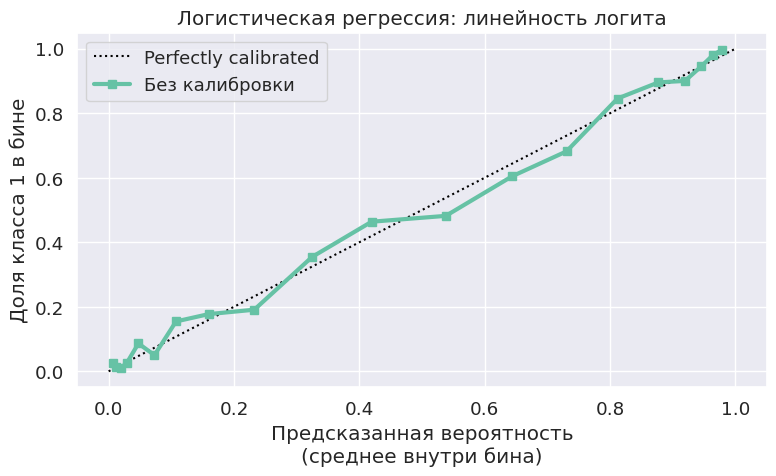

In [98]:
calibration_curves_lr(
    [(lr_linear, "Без калибровки")],
    X_test_linear,
    y_test_linear,
    title="Логистическая регрессия: линейность логита",
)

Кривая проходит близко к диагонали. Небольшие отклонения остаются: в каждом интервале вероятностей мы оцениваем долю класса 1 по конечному числу объектов.

Теперь проверим, помогут ли методы калибровки улучшить результат.

In [99]:
lr_sigmoid_linear = calibrated_classifier(
    lr_linear, X_calib_linear, y_calib_linear, method="sigmoid"
)
lr_isotonic_linear = calibrated_classifier(
    lr_linear, X_calib_linear, y_calib_linear, method="isotonic"
)

Сравним оба метода со случаем отсутствия калибровки.

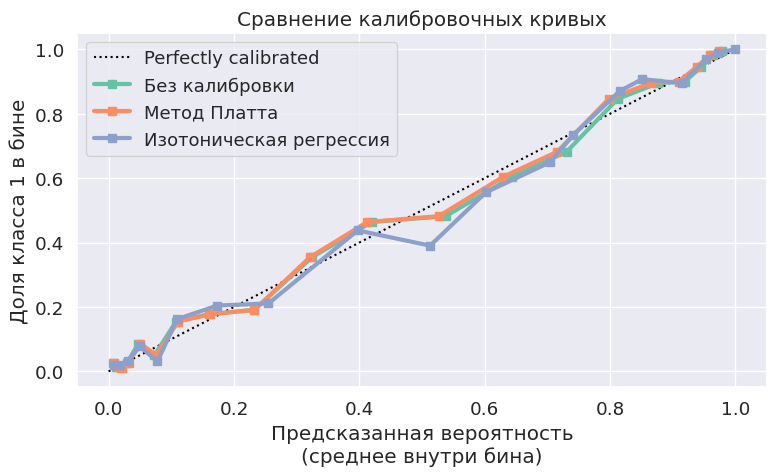

In [100]:
clf_list_linear = [
    (lr_linear, "Без калибровки"),
    (lr_sigmoid_linear, "Метод Платта"),
    (lr_isotonic_linear, "Изотоническая регрессия"),
]

calibration_curves_lr(clf_list_linear, X_test_linear, y_test_linear)

Метод Платта почти не изменил калибровочную кривую. Изотоническая регрессия дает небольшие изменения, но не приближает всю кривую к диагонали: она тоже обучается по конечной калибровочной выборке.

**Вывод:** Когда логит вероятности линейно зависит от признаков и данных достаточно, логистическая регрессия уже хорошо оценивает вероятности. Дополнительная калибровка не обязана улучшать результат.

#### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">2.2</span> <span style="color:inherit;">Нелинейность логита</span>

Теперь сгенерируем выборку, в которой зависимость вероятности класса 1 от признаков сложнее. Классы расположим в четырех кластерах, а также добавим фоновый шум из точек разных классов.


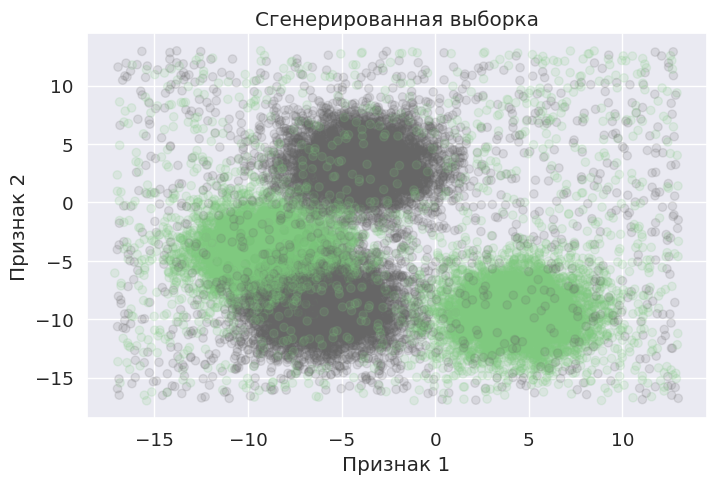

In [101]:
X_nonlinear, y_nonlinear = make_blobs(
    n_samples=20000, n_features=2, centers=4, cluster_std=2.1, random_state=21
)
y_nonlinear = (y_nonlinear >= 2).astype(int)

# Шум
rng_nonlinear = np.random.default_rng(42)
n_noise_nonlinear = 2000
X_nonlinear = np.vstack([X_nonlinear, rng_nonlinear.uniform(-17, 13, size=(n_noise_nonlinear, 2))])
y_nonlinear = np.hstack([y_nonlinear, rng_nonlinear.binomial(1, 0.5, size=n_noise_nonlinear)])

# Посмотрим на выборку
plt.figure(figsize=(8, 5))
plt.title("Сгенерированная выборка")
plt.scatter(X_nonlinear[:, 0], X_nonlinear[:, 1], c=y_nonlinear, alpha=0.15, cmap="Accent")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.show()

Разделим выборку на обучающую, калибровочную и тестовую части в пропорции 60% / 20% / 20%. Как и раньше, модель обучается только на обучающей части, методы калибровки — на калибровочной. Результаты сравним на тестовой части.


In [102]:
X_temp_nonlinear, X_test_nonlinear, y_temp_nonlinear, y_test_nonlinear = train_test_split(
    X_nonlinear, y_nonlinear, test_size=0.2, random_state=42, stratify=y_nonlinear
)
X_train_nonlinear, X_calib_nonlinear, y_train_nonlinear, y_calib_nonlinear = train_test_split(
    X_temp_nonlinear, y_temp_nonlinear, test_size=0.25, random_state=42, stratify=y_temp_nonlinear
)

Обучим логистическую регрессию.


In [103]:
lr_nonlinear = LogisticRegression(max_iter=1000).fit(X_train_nonlinear, y_train_nonlinear)

Посмотрим, насколько предсказанные вероятности соответствуют реальным частотам.


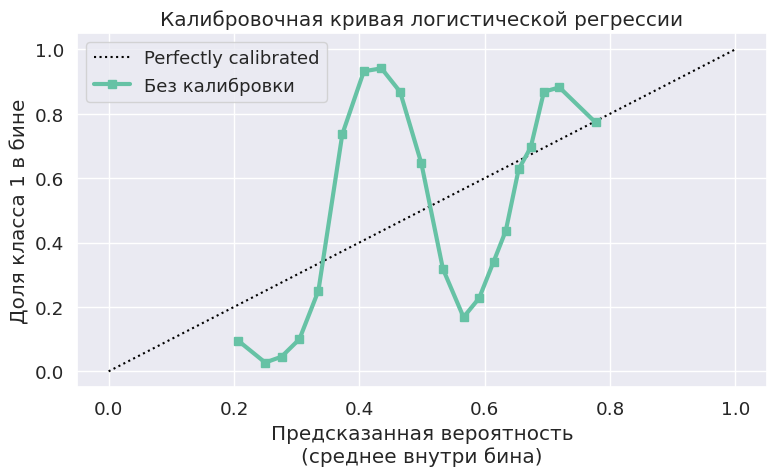

In [104]:
calibration_curves_lr(
    [(lr_nonlinear, "Без калибровки")],
    X_test_nonlinear,
    y_test_nonlinear,
    figsize=(8, 5),
    title="Калибровочная кривая логистической регрессии",
)

Видим, что кривая сильно отклоняется от диагонали. При этом отклонение меняет направление:

* в одних группах модель недооценивает вероятность класса 1;
* в других — переоценивает ее.

Линейный логит не позволяет описать расположение всех четырех кластеров. В отличие от предыдущего примера, форма зависимости, заданная моделью, не соответствует данным.

Посмотрим, поможет ли калибровка.


In [105]:
lr_platt_nonlinear = calibrated_classifier(
    lr_nonlinear, X_calib_nonlinear, y_calib_nonlinear, method="sigmoid"
)
lr_isotonic_nonlinear = calibrated_classifier(
    lr_nonlinear, X_calib_nonlinear, y_calib_nonlinear, method="isotonic"
)

Сравним оба метода со случаем отсутствия калибровки.


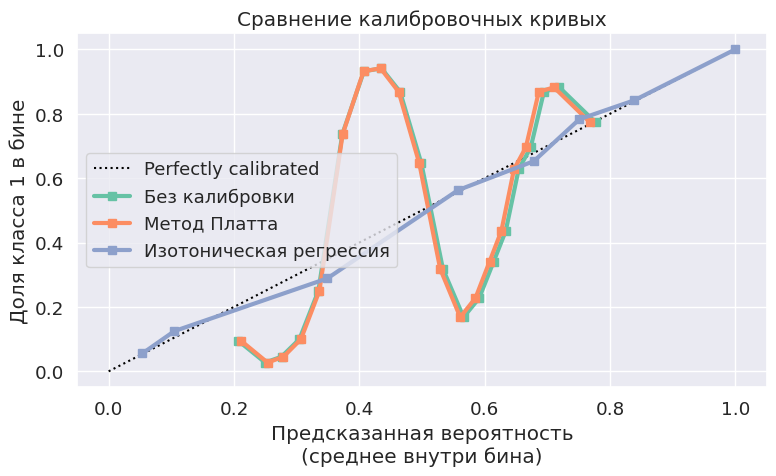

In [106]:
clf_list_nonlinear = [
    (lr_nonlinear, "Без калибровки"),
    (lr_platt_nonlinear, "Метод Платта"),
    (lr_isotonic_nonlinear, "Изотоническая регрессия"),
]

calibration_curves_lr(clf_list_nonlinear, X_test_nonlinear, y_test_nonlinear, figsize=(8, 5))

В этом примере изотоническая регрессия заметно приблизила кривую к диагонали, а метод Платта практически не поменял ее. Дело в том, что метод Платта меняет масштаб и смещение исходного логита. Такое преобразование недостаточно гибкое для наблюдаемой зависимости. Изотоническая регрессия может присвоить одинаковую вероятность целому диапазону исходных скоров: частоты внутри объединенной группы оказываются ближе к предсказанию.

Посмотрим на карты вероятностей до и после изотонической калибровки. Чем темнее зеленый цвет, тем выше предсказанная вероятность класса 1. Бирюзовые точки соответствуют классу 0, розовые — классу 1.

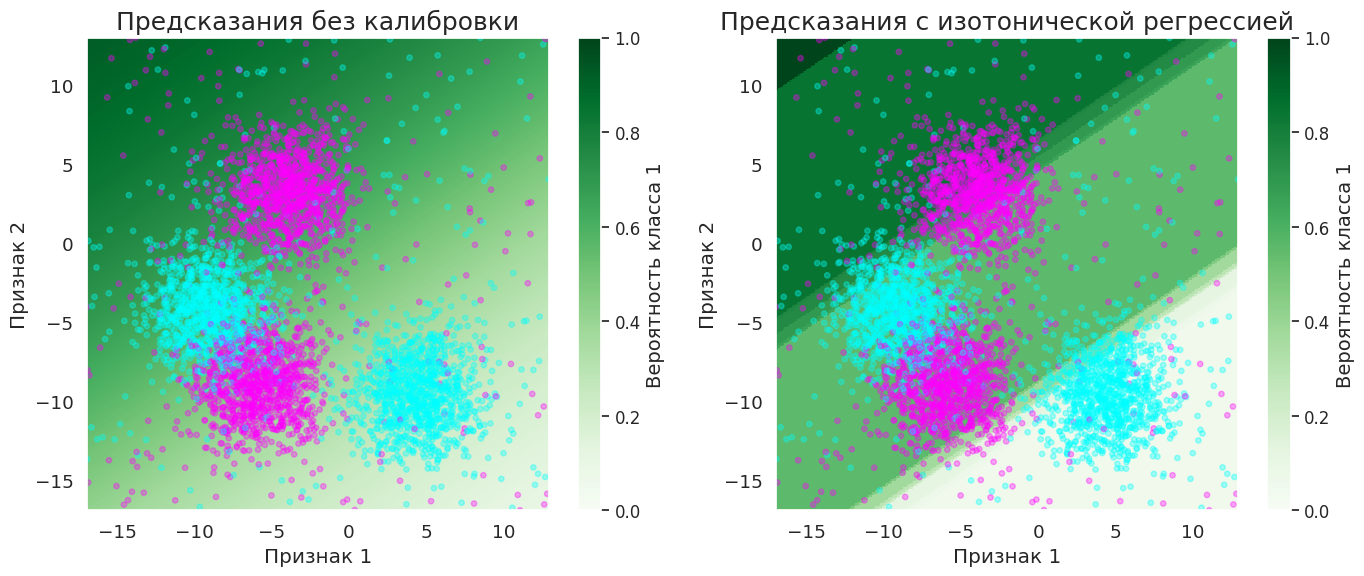

In [107]:
fig_nonlinear, axes_nonlinear = plt.subplots(1, 2, figsize=(14, 6))

draw_prob_predictions_lr(
    lr_nonlinear, X_test_nonlinear, y_test_nonlinear, name="без калибровки", ax=axes_nonlinear[0]
)
draw_prob_predictions_lr(
    lr_isotonic_nonlinear,
    X_test_nonlinear,
    y_test_nonlinear,
    name="с изотонической регрессией",
    ax=axes_nonlinear[1],
)

plt.tight_layout()
plt.show()

После калибровки изменились значения вероятностей, но сохранилось общее направление их изменения. Объекты с одинаковым исходным скором по-прежнему получают одинаковые вероятности, даже если они расположены в разных кластерах.

**Вывод:** Калибровка может улучшить соответствие вероятностей реальным частотам, но она не восстанавливает зависимость от признаков, которую модель не смогла описать. Для изменения самой зависимости можно, например, добавить нелинейные признаки. Это уже изменение модели, а не калибровка ее вероятностей.


#### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">2.3</span> <span style="color:inherit;">Логистическая регрессия на реальных данных</span>

Вернемся к задаче кредитного скоринга из первой части. Обучим логистическую регрессию на тех же признаках и тех же обучающей, калибровочной и тестовой выборках, что и kNN.

Перед обучением приведем признаки к одному масштабу. Параметры масштабирования вычисляются только по обучающей выборке.

In [108]:
lr_credit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=42))
lr_credit.fit(X_train_credit, y_train_credit)

y_pred_proba_lr_credit = lr_credit.predict_proba(X_test_credit)[:, 1]

Посмотрим на калибровочную кривую логистической регрессии без калибровки.

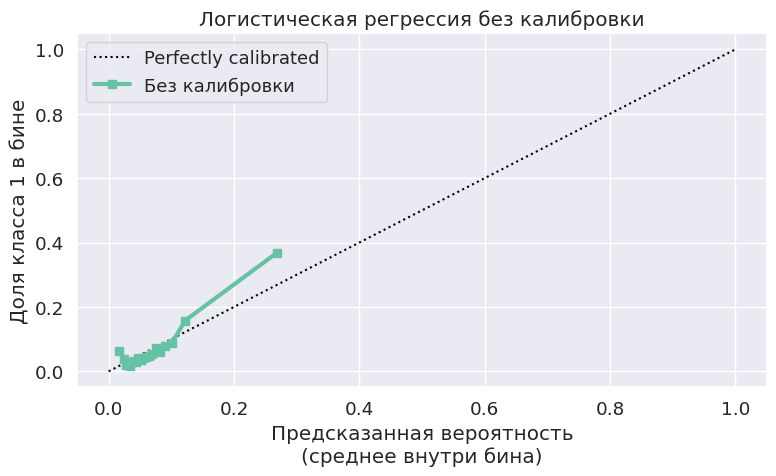

In [109]:
calibration_curves_lr(
    [(lr_credit, "Без калибровки")],
    X_test_credit,
    y_test_credit,
    title="Логистическая регрессия без калибровки",
)

Как соотносятся предсказанные вероятности с частотами дефолта? В каких областях модель недооценивает или переоценивает риск?

Посмотрим также на привычные категории кредитного риска.

In [110]:
risk_table_lr_credit = get_credit_risk_decisions(y_test_credit, y_pred_proba_lr_credit)
risk_table_lr_credit

,risk_category,Предсказанная вероятность дефолта,Фактическая вероятность дефолта,Количество заемщиков,Количество дефолтов
0,Одобрить (стандартная ставка),0.0152,0.0771,1050,81
1,Одобрить (повышенная ставка),0.0355,0.0288,12861,370
2,Дополнительная проверка,0.0708,0.0568,12313,699
3,Отклонить,0.1762,0.2264,3776,855


Сравним среднюю предсказанную вероятность дефолта с фактической долей дефолтов в каждой категории. Обратим внимание и на количество заемщиков: для небольшой группы наблюдаемая доля может заметно колебаться.

Теперь применим метод Платта и изотоническую регрессию. Модель уже обучена; для калибровки используем отдельную калибровочную выборку.

In [111]:
lr_credit_platt = calibrated_classifier(lr_credit, X_calib_credit, y_calib_credit, method="sigmoid")
lr_credit_isotonic = calibrated_classifier(
    lr_credit, X_calib_credit, y_calib_credit, method="isotonic"
)

y_pred_proba_lr_credit_platt = lr_credit_platt.predict_proba(X_test_credit)[:, 1]
y_pred_proba_lr_credit_isotonic = lr_credit_isotonic.predict_proba(X_test_credit)[:, 1]

Сравним результаты с исходной моделью.

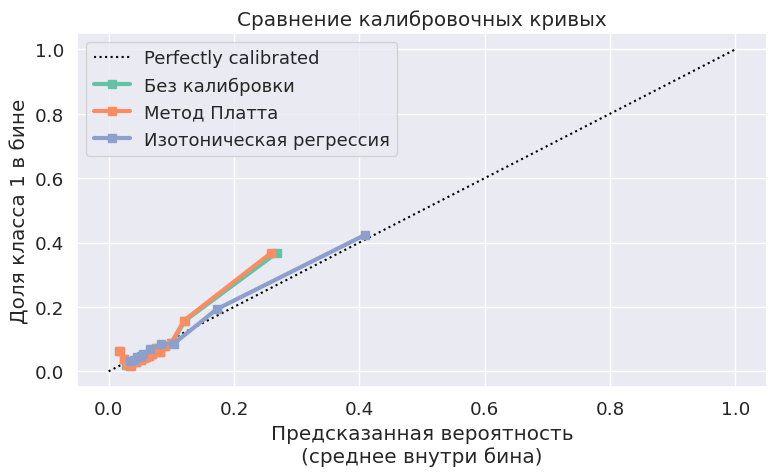

In [112]:
clf_list_lr_credit = [
    (lr_credit, "Без калибровки"),
    (lr_credit_platt, "Метод Платта"),
    (lr_credit_isotonic, "Изотоническая регрессия"),
]

calibration_curves_lr(clf_list_lr_credit, X_test_credit, y_test_credit)

Посмотрим, как калибровка методом Платта повлияла на решения об одобрении кредита.

In [113]:
risk_table_lr_credit_platt = get_credit_risk_decisions(y_test_credit, y_pred_proba_lr_credit_platt)
risk_table_lr_credit_platt

,risk_category,Предсказанная вероятность дефолта,Фактическая вероятность дефолта,Количество заемщиков,Количество дефолтов
0,Одобрить (стандартная ставка),0.0150,0.0898,857,77
1,Одобрить (повышенная ставка),0.0359,0.0288,12786,368
2,Дополнительная проверка,0.0707,0.0564,12680,715
3,Отклонить,0.1735,0.2298,3677,845


Теперь посмотрим на те же категории после изотонической регрессии.

In [114]:
risk_table_lr_credit_isotonic = get_credit_risk_decisions(
    y_test_credit, y_pred_proba_lr_credit_isotonic
)
risk_table_lr_credit_isotonic

,risk_category,Предсказанная вероятность дефолта,Фактическая вероятность дефолта,Количество заемщиков,Количество дефолтов
0,Одобрить (стандартная ставка),0.0020,0.0000,4,0
1,Одобрить (повышенная ставка),0.0369,0.0346,17616,609
2,Дополнительная проверка,0.0660,0.0648,9292,602
3,Отклонить,0.2409,0.2571,3088,794


Сравним обе модели на одной тестовой выборке. На графиках используем одинаковые оси и одинаковые настройки разбиения на бины.

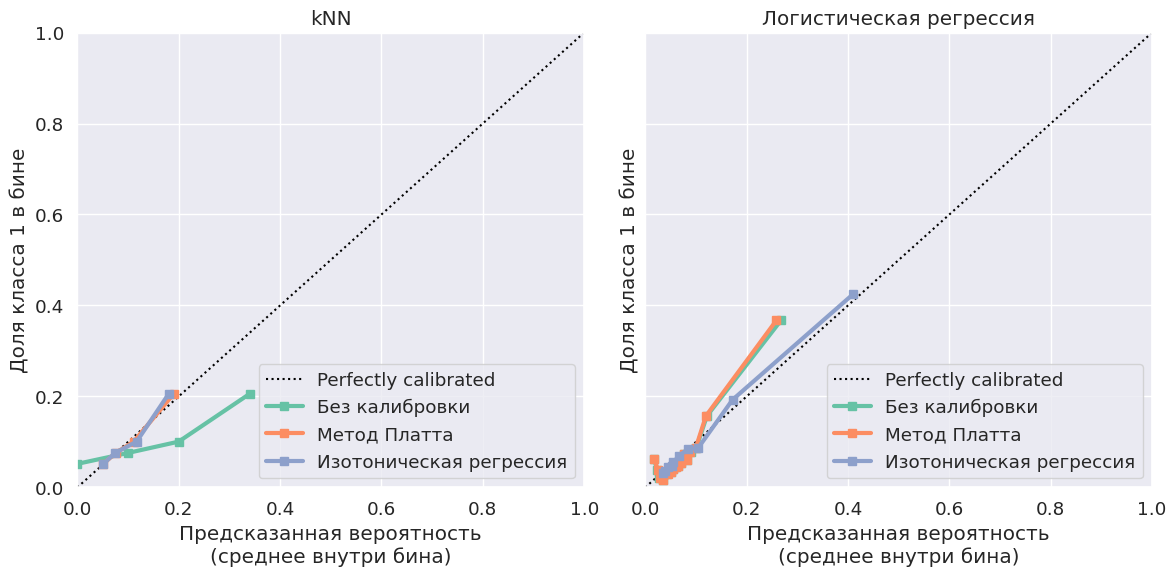

In [115]:
credit_predictions = {
    ("kNN", "Без калибровки"): y_pred_proba_uncalibrated,
    ("kNN", "Метод Платта"): y_pred_proba_platt,
    ("kNN", "Изотоническая регрессия"): y_pred_proba_isotonic,
    ("Логистическая регрессия", "Без калибровки"): y_pred_proba_lr_credit,
    ("Логистическая регрессия", "Метод Платта"): y_pred_proba_lr_credit_platt,
    ("Логистическая регрессия", "Изотоническая регрессия"): y_pred_proba_lr_credit_isotonic,
}

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
for ax, model_name in zip(axes, ["kNN", "Логистическая регрессия"]):
    for (name, calibration), probabilities in credit_predictions.items():
        if name == model_name:
            CalibrationDisplay.from_predictions(
                y_test_credit,
                probabilities,
                n_bins=20,
                strategy="quantile",
                lw=3,
                name=calibration,
                ax=ax,
            )
    ax.set_title(model_name)
    ax.set_xlabel("Предсказанная вероятность\n(среднее внутри бина)")
    ax.set_ylabel("Доля класса 1 в бине")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
#     ax.legend(fontsize=13)

plt.tight_layout()
plt.show()

Дополнительно оценим качество предсказанных вероятностей с помощью двух метрик.

**Brier score** — средняя квадратичная ошибка предсказанных вероятностей:

$$
\mathrm{Brier\ score} = \frac{1}{n}\sum_{i=1}^{n}(\widehat{p}_i-y_i)^2.
$$

**Log loss (бинарная кросс-энтропия)**:

$$
\mathrm{Log\ loss} = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i\log\widehat{p}_i + (1-y_i)\log(1-\widehat{p}_i)\right].
$$

Здесь $y_i\in\{0,1\}$ — истинная метка объекта, $\widehat{p}_i$ — предсказанная вероятность класса 1, $n$ — число объектов. Для обеих метрик **меньшее значение лучше**. Кросс-энтропия особенно сильно штрафует уверенные ошибочные предсказания: например, вероятность дефолта, близкую к нулю, для клиента с фактическим дефолтом.

Если модель присвоила нулевую вероятность событию, которое произошло, кросс-энтропия бесконечна. При численном вычислении вероятности ограничивают значениями, чуть отличными от 0 и 1.

Эти метрики оценивают качество вероятностных предсказаний в целом, а не только калибровку. Поэтому будем рассматривать их вместе с калибровочными кривыми и таблицами рисков.

In [116]:
metrics_credit = pd.DataFrame(
    [
        {
            "Модель": model_name,
            "Калибровка": calibration,
            "Brier score": brier_score_loss(y_test_credit, probabilities),
            "Log loss": log_loss(y_test_credit, probabilities),
        }
        for (model_name, calibration), probabilities in credit_predictions.items()
    ]
)

metrics_credit.round(4)

,Модель,Калибровка,Brier score,Log loss
0,kNN,Без калибровки,0.0644,1.2514
1,kNN,Метод Платта,0.0613,0.2400
2,kNN,Изотоническая регрессия,0.0613,0.2401
3,Логистическая регрессия,Без калибровки,0.0572,0.2222
4,Логистическая регрессия,Метод Платта,0.0573,0.2224
5,Логистическая регрессия,Изотоническая регрессия,0.0562,0.2162


Сравним результаты:
* Для какой модели калибровка дает больший эффект?
* Одинаковый ли метод калибровки лучше для kNN и логистической регрессии?
* Подтверждают ли обе метрики наблюдения по кривым и категориям риска?

**Вывод:** Логистическая регрессия не гарантирует хорошую калибровку на любых данных. Влияние калибровки на качество вероятностей оцениваем на отдельной тестовой выборке. При этом сравнение относится к тем конфигурациям kNN и логистической регрессии, которые мы обучили в ноутбуке.

<div style="box-sizing:border-box;max-width:100%;margin-top:42px;padding:18px 0 4px;border-top:1px solid rgba(127, 127, 127, 0.28);color:inherit;font-size:0.9em;line-height:1.5;"><img src="https://thetahat.ru/images/logo_thetahat.png" alt="ThetaHat" style="display:block!important;width:34px!important;max-width:34px!important;height:auto!important;margin:0 0 9px 0!important;padding:0!important;">© 2026 команда <a href="https://thetahat.ru/" style="color:inherit;font-weight:750;text-decoration:underline;text-decoration-color:#F13A3F;text-underline-offset:3px;">ThetaHat</a> для ШАД</div>